In [ ]:
!git clone https://github.com/IDEA-Research/Grounded-SAM-2.git


fatal: destination path 'Grounded-SAM-2' already exists and is not an empty directory.
/content/Grounded-SAM-2
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user


In [ ]:
%cd Grounded-SAM-2

!pip install -e . -q
!pip install --no-build-isolation -e grounding_dino -q
!pip install transformers einops timm supervision -q

%cd checkpoints
!bash download_ckpts.sh
%cd ..

%cd gdino_checkpoints
!bash download_ckpts.sh
%cd ..

In [ ]:
!pip install transformers==4.49.0 -q

In [23]:
from google.colab import files
import shutil
import os

# Option A: Upload from local machine
uploaded = files.upload()
VIDEO_FILENAME = list(uploaded.keys())[0]
VIDEO_PATH = os.path.join('.', VIDEO_FILENAME)
print(f"Uploaded: {VIDEO_PATH}")

# Option B: If your video is on Google Drive, uncomment below instead:
# from google.colab import drive
# drive.mount('/content/drive')
# VIDEO_PATH = '/content/drive/MyDrive/path/to/your/video.mp4'

Saving nuscenes_video copy.mp4 to nuscenes_video copy (1).mp4
Uploaded: ./nuscenes_video copy (1).mp4


In [24]:
# ============ EDIT THESE ============
TEXT_PROMPT = "traffic sign. road sign. stop sign. speed limit sign. warning sign. street sign."
OUTPUT_VIDEO_PATH = "./traffic_signs_tracked.mp4"
SOURCE_VIDEO_FRAME_DIR = "./custom_video_frames"
SAVE_TRACKING_RESULTS_DIR = "./tracking_results"
CROP_OUTPUT_DIR = "./sign_crops"  # where we save cropped sign images

PROMPT_TYPE_FOR_VIDEO = "mask"  # "point", "box", or "mask" (mask is most stable)
BOX_THRESHOLD = 0.25  # lower = more detections, higher = fewer but more confident
TEXT_THRESHOLD = 0.25

# SAM 2 model config (use small for T4 to save VRAM)
SAM2_CHECKPOINT = "./checkpoints/sam2.1_hiera_small.pt"
SAM2_MODEL_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"
# If you have more VRAM, try the large model:
# SAM2_CHECKPOINT = "./checkpoints/sam2.1_hiera_large.pt"
# SAM2_MODEL_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

# Grounding DINO model
GROUNDING_DINO_MODEL = "IDEA-Research/grounding-dino-tiny"
# =====================================

In [25]:
import cv2
import os

os.makedirs(SOURCE_VIDEO_FRAME_DIR, exist_ok=True)
os.makedirs(SAVE_TRACKING_RESULTS_DIR, exist_ok=True)
os.makedirs(CROP_OUTPUT_DIR, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video: {total_frames} frames, {fps:.1f} FPS, {frame_width}x{frame_height}")
print(f"Duration: {total_frames/fps:.1f} seconds")

# Optional: subsample frames if video is long (process every Nth frame)
# Set FRAME_STEP = 1 for all frames, or higher to skip frames
FRAME_STEP = 1  # increase this if you run out of memory or time

frame_idx = 0
saved_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % FRAME_STEP == 0:
        frame_path = os.path.join(SOURCE_VIDEO_FRAME_DIR, f"{saved_count:05d}.jpg")
        cv2.imwrite(frame_path, frame)
        saved_count += 1
    frame_idx += 1

cap.release()
print(f"Saved {saved_count} frames to {SOURCE_VIDEO_FRAME_DIR}")

Video: 404 frames, 5.0 FPS, 1600x900
Duration: 80.8 seconds
Saved 404 frames to ./custom_video_frames


In [26]:
import torch
import numpy as np
from PIL import Image
from sam2.build_sam import build_sam2_video_predictor, build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from utils.track_utils import sample_points_from_masks
from utils.video_utils import create_video_from_images

# ---- Initialize models ----
# Use bfloat16 for memory efficiency on T4
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()
if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading SAM 2 video predictor...")
video_predictor = build_sam2_video_predictor(SAM2_MODEL_CONFIG, SAM2_CHECKPOINT, device=device)

print("Loading SAM 2 image predictor...")
sam2_model = build_sam2(SAM2_MODEL_CONFIG, SAM2_CHECKPOINT, device=device)
image_predictor = SAM2ImagePredictor(sam2_model)

print("Loading Grounding DINO...")
processor = AutoProcessor.from_pretrained(GROUNDING_DINO_MODEL)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(GROUNDING_DINO_MODEL).to(device)

print("All models loaded!")

Loading SAM 2 video predictor...
Loading SAM 2 image predictor...
Loading Grounding DINO...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

All models loaded!


In [27]:
# Run Grounding DINO
inputs = processor(images=img, text=TEXT_PROMPT, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = grounding_model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    threshold=BOX_THRESHOLD,
    target_sizes=[img.size[::-1]]
)

input_boxes = results[0]["boxes"].cpu().numpy()
labels = results[0]["text_labels"]  # changed from "labels" to "text_labels"
scores = results[0]["scores"].cpu().numpy()

In [28]:
# Auto-find first frame with detections
for try_idx in range(0, len(frame_names), 10):  # check every 10th frame
    frame_path = os.path.join(SOURCE_VIDEO_FRAME_DIR, frame_names[try_idx])
    img = Image.open(frame_path)

    inputs = processor(images=img, text=TEXT_PROMPT, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = grounding_model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        threshold=BOX_THRESHOLD,
        target_sizes=[img.size[::-1]]
    )

    if len(results[0]["boxes"]) > 0:
        ann_frame_idx = try_idx
        input_boxes = results[0]["boxes"].cpu().numpy()
        labels = results[0]["text_labels"]
        scores = results[0]["scores"].cpu().numpy()
        print(f"Found {len(input_boxes)} detections on frame {try_idx}!")
        for i, (label, score, box) in enumerate(zip(labels, scores, input_boxes)):
            print(f"  [{i}] {label}: {score:.3f} | box: {box.astype(int)}")
        break
else:
    print("No detections in any sampled frame. Try lowering threshold or broadening TEXT_PROMPT.")

Found 3 detections on frame 10!
  [0] sign: 0.343 | box: [697 406 723 433]
  [1] road sign sign: 0.278 | box: [694 401 727 438]
  [2] traffic sign: 0.293 | box: [1264  436 1288  446]


In [29]:
# ---- Step 4b: Generate SAM 2 masks from Grounding DINO boxes ----

if len(input_boxes) > 0:
    # Use SAM 2 image predictor to get masks from boxes
    image_predictor.set_image(np.array(img.convert("RGB")))
    masks, mask_scores, _ = image_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )
    # masks shape: (N, 1, H, W) → squeeze to (N, H, W)
    if masks.ndim == 4:
        masks = masks.squeeze(1)

    print(f"Generated {len(masks)} masks")
else:
    print("No boxes to generate masks from. Check detections above.")
    masks = np.array([])

Generated 3 masks


In [30]:
# ---- Step 4c: Track detected signs across all frames with SAM 2 video predictor ----

if len(input_boxes) > 0:
    # Initialize video predictor state
    inference_state = video_predictor.init_state(video_path=SOURCE_VIDEO_FRAME_DIR)
    video_predictor.reset_state(inference_state)

    # Add detections from the annotated frame
    if PROMPT_TYPE_FOR_VIDEO == "point":
        # Sample points from masks
        all_sample_points = sample_points_from_masks(masks=masks, num_points=10)
        for obj_id, points in enumerate(all_sample_points):
            labels_for_points = np.ones(len(points), dtype=np.int32)
            _, out_obj_ids, out_mask_logits = video_predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=ann_frame_idx,
                obj_id=obj_id,
                points=points,
                labels=labels_for_points,
            )
    elif PROMPT_TYPE_FOR_VIDEO == "box":
        for obj_id, box in enumerate(input_boxes):
            _, out_obj_ids, out_mask_logits = video_predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=ann_frame_idx,
                obj_id=obj_id,
                box=box,
            )
    elif PROMPT_TYPE_FOR_VIDEO == "mask":
        for obj_id, mask in enumerate(masks):
            _, out_obj_ids, out_mask_logits = video_predictor.add_new_mask(
                inference_state=inference_state,
                frame_idx=ann_frame_idx,
                obj_id=obj_id,
                mask=mask,
            )

    # Propagate tracking through all frames
    print("Propagating tracking across all frames...")
    video_segments = {}  # {frame_idx: {obj_id: mask}}
    for out_frame_idx, out_obj_ids, out_mask_logits in video_predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    print(f"Tracking complete! Got segments for {len(video_segments)} frames")
else:
    print("Skipping tracking — no detections found.")
    video_segments = {}

frame loading (JPEG): 100%|██████████| 404/404 [00:22<00:00, 18.29it/s]


Propagating tracking across all frames...


propagate in video: 100%|██████████| 394/394 [07:28<00:00,  1.14s/it]

Tracking complete! Got segments for 394 frames


In [31]:
import json

# Color palette for different tracked objects
COLORS = [
    (0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0),
    (255, 0, 255), (0, 255, 255), (128, 255, 0), (255, 128, 0)
]

all_crops = []  # collect (frame_idx, obj_id, crop_path, bbox)

for frame_idx in sorted(video_segments.keys()):
    frame_path = os.path.join(SOURCE_VIDEO_FRAME_DIR, frame_names[frame_idx])
    frame = cv2.imread(frame_path)
    annotated_frame = frame.copy()

    for obj_id, mask in video_segments[frame_idx].items():
        mask_2d = mask.squeeze()  # (H, W)
        if mask_2d.sum() == 0:
            continue

        color = COLORS[obj_id % len(COLORS)]

        # Draw semi-transparent mask overlay
        overlay = annotated_frame.copy()
        overlay[mask_2d > 0] = color
        annotated_frame = cv2.addWeighted(annotated_frame, 0.7, overlay, 0.3, 0)

        # Draw bounding box from mask
        ys, xs = np.where(mask_2d > 0)
        if len(xs) > 0:
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(annotated_frame, f"sign_{obj_id}", (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Crop the detected sign region (with some padding)
            pad = 10
            h, w = frame.shape[:2]
            cx1 = max(0, x1 - pad)
            cy1 = max(0, y1 - pad)
            cx2 = min(w, x2 + pad)
            cy2 = min(h, y2 + pad)
            crop = frame[cy1:cy2, cx1:cx2]

            # Save crop (sample every N frames to avoid too many crops)
            CROP_EVERY_N_FRAMES = 10  # adjust as needed
            if frame_idx % CROP_EVERY_N_FRAMES == 0 and crop.size > 0:
                crop_filename = f"frame{frame_idx:05d}_obj{obj_id}.jpg"
                crop_path = os.path.join(CROP_OUTPUT_DIR, crop_filename)
                cv2.imwrite(crop_path, crop)
                all_crops.append({
                    "frame_idx": frame_idx,
                    "obj_id": obj_id,
                    "crop_path": crop_path,
                    "bbox": [int(x1), int(y1), int(x2), int(y2)]
                })

    # Save annotated frame
    cv2.imwrite(os.path.join(SAVE_TRACKING_RESULTS_DIR, f"annotated_{frame_idx:05d}.jpg"), annotated_frame)

print(f"Saved {len(all_crops)} sign crops to {CROP_OUTPUT_DIR}")
print(f"Saved annotated frames to {SAVE_TRACKING_RESULTS_DIR}")

Saved 3 sign crops to ./sign_crops
Saved annotated frames to ./tracking_results


In [32]:
# ---- Create output video from annotated frames ----
annotated_frames = sorted([f for f in os.listdir(SAVE_TRACKING_RESULTS_DIR) if f.endswith('.jpg')])

if len(annotated_frames) > 0:
    first = cv2.imread(os.path.join(SAVE_TRACKING_RESULTS_DIR, annotated_frames[0]))
    h, w = first.shape[:2]
    out_fps = fps / FRAME_STEP  # adjust for frame subsampling

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_video = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, out_fps, (w, h))

    for fname in annotated_frames:
        frame = cv2.imread(os.path.join(SAVE_TRACKING_RESULTS_DIR, fname))
        out_video.write(frame)

    out_video.release()
    print(f"Output video saved to {OUTPUT_VIDEO_PATH}")
else:
    print("No annotated frames to create video from.")

Output video saved to ./traffic_signs_tracked.mp4


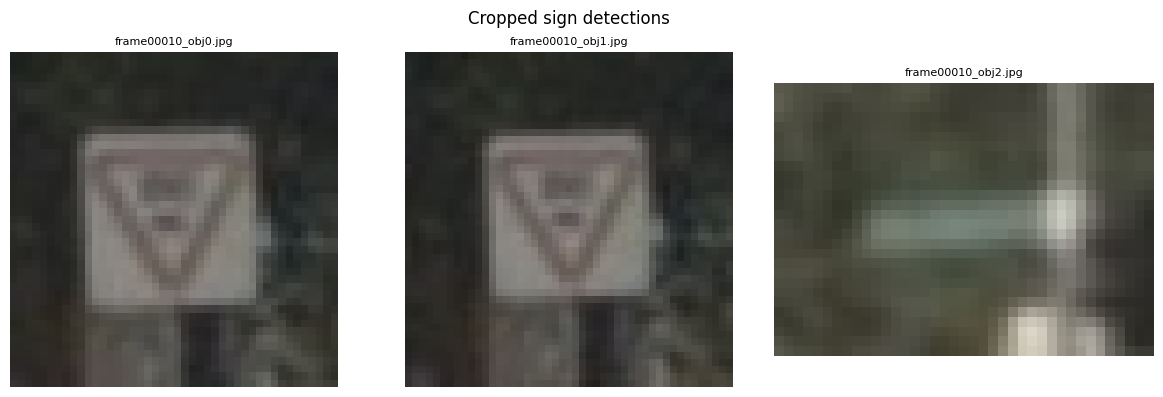

In [33]:
# ---- Preview some crops ----
crop_files = sorted(os.listdir(CROP_OUTPUT_DIR))[:12]  # show up to 12

if len(crop_files) > 0:
    cols = min(4, len(crop_files))
    rows = (len(crop_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for i, fname in enumerate(crop_files):
        crop_img = cv2.imread(os.path.join(CROP_OUTPUT_DIR, fname))
        crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(crop_img)
        axes[i].set_title(fname, fontsize=8)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle("Cropped sign detections")
    plt.tight_layout()
    plt.show()
else:
    print("No crops found. Check detection results above.")

In [35]:
from transformers import AutoProcessor as FlorenceProcessor, AutoModelForCausalLM

print("Loading Florence-2 model (this may take a minute)...")
florence_model_id = "microsoft/Florence-2-base"
# Use Florence-2-large for better results if VRAM allows:
# florence_model_id = "microsoft/Florence-2-large"

florence_processor = FlorenceProcessor.from_pretrained(florence_model_id, trust_remote_code=True)
florence_model = AutoModelForCausalLM.from_pretrained(
    florence_model_id, trust_remote_code=True, torch_dtype=torch.float16
).to(device)

print("Florence-2 loaded!")

Loading Florence-2 model (this may take a minute)...


You are using a model of type florence2 to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


AttributeError: TokenizersBackend has no attribute additional_special_tokens